In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

print("CWD :", Path.cwd())
print("ROOT:", ROOT)
print("flux dir exists:", (ROOT / "data" / "flux").exists())



CWD : C:\Users\Alber\Documents\PhD\XRF\notebooks
ROOT: C:\Users\Alber\Documents\PhD\XRF
flux dir exists: True


In [4]:
from xrf_model.config import load_config
from xrf_model.pipeline import run_one, run_many

cfg = load_config("configs/deimos.yml")

flux_file = ROOT / "data" / "flux" / "M1_1000bin.qdp"
print("flux exists:", flux_file.exists(), flux_file)

res_one = run_one(flux_file, cfg)
res_one.keys()


flux exists: True C:\Users\Alber\Documents\PhD\XRF\data\flux\M1_1000bin.qdp
SAMPLE: CI
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\M1_1000bin\M1_1000bin_CI_coherent_spectrum.txt
SAMPLE: mantle_mars
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\M1_1000bin\M1_1000bin_mantle_mars_coherent_spectrum.txt


dict_keys(['CI', 'mantle_mars'])

In [5]:
flux_files = sorted((ROOT / "data" / "flux").glob("*.qdp"))
flux_files[:5], len(flux_files)

([WindowsPath('C:/Users/Alber/Documents/PhD/XRF/data/flux/A3_1000bin.qdp'),
  WindowsPath('C:/Users/Alber/Documents/PhD/XRF/data/flux/A3_DENSE_1000bin.qdp'),
  WindowsPath('C:/Users/Alber/Documents/PhD/XRF/data/flux/A3_THIN_1000bin.qdp'),
  WindowsPath('C:/Users/Alber/Documents/PhD/XRF/data/flux/B1_1000bin.qdp'),
  WindowsPath('C:/Users/Alber/Documents/PhD/XRF/data/flux/B1_DENSE_1000bin.qdp')],
 12)

In [6]:
results = run_many(flux_files, cfg)
list(results.keys())[:5]

SAMPLE: CI
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_1000bin\A3_1000bin_CI_coherent_spectrum.txt
SAMPLE: mantle_mars
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_1000bin\A3_1000bin_mantle_mars_coherent_spectrum.txt
SAMPLE: CI
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_DENSE_1000bin\A3_DENSE_1000bin_CI_coherent_spectrum.txt
SAMPLE: mantle_mars
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_DENSE_1000bin\A3_DENSE_1000bin_mantle_mars_coherent_spectrum.txt
SAMPLE: CI
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_THIN_1000bin\A3_THIN_1000bin_CI_coherent_spectrum.txt
SAMPLE: mantle_mars
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\A3_THIN_1000bin\A3_THIN_1000bin_mantle_mars_coherent_spectrum.txt
SAMPLE: CI
→ Saved coherent spectrum to C:\Users\Alber\Documents\PhD\XRF\results\deimos\B1_1

['A3_1000bin',
 'A3_DENSE_1000bin',
 'A3_THIN_1000bin',
 'B1_1000bin',
 'B1_DENSE_1000bin']

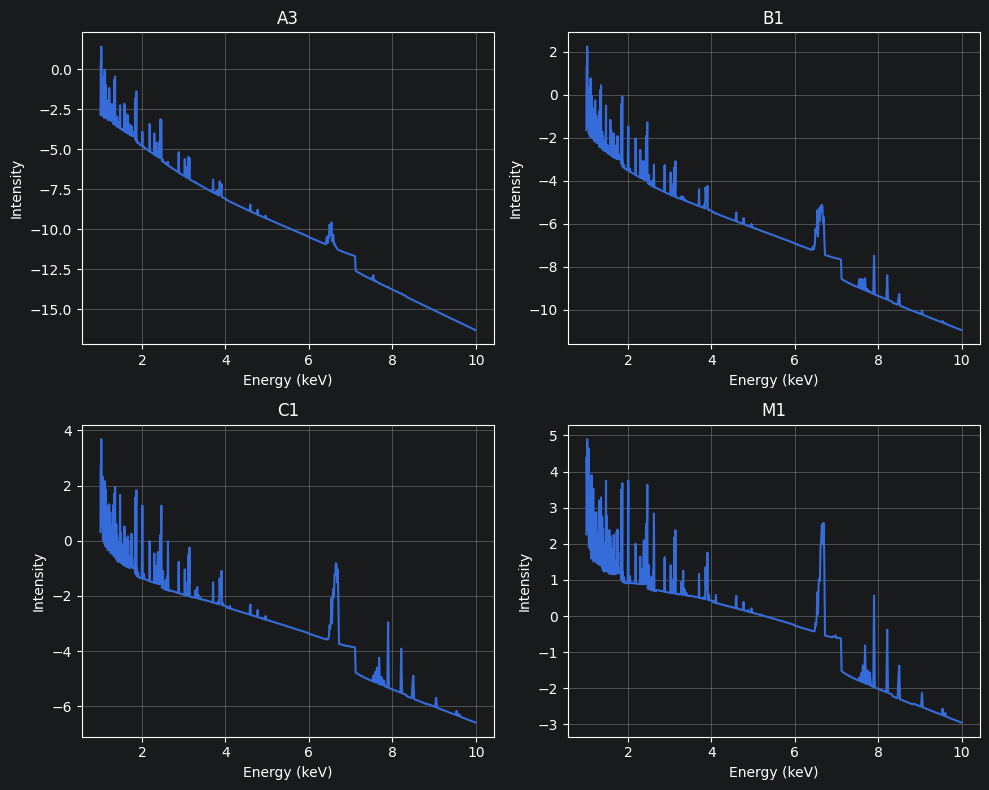

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = "../results/deimos/"
files = {
    "A3": folder + "A3_1000bin/A3_1000bin_CI_results.xlsx",
    "B1": folder + "B1_1000bin/B1_1000bin_CI_results.xlsx",
    "C1": folder + "C1_1000bin/C1_1000bin_CI_results.xlsx",
    "M1": folder + "M1_1000bin/M1_1000bin_CI_results.xlsx"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (label, file) in enumerate(files.items()):
    df = pd.read_excel(file)
    energy = df["Energy"]
    intensity = df["I_coherent"]
    log_I = np.log(intensity)
    axes[i].plot(energy, log_I)
    axes[i].set_title(label)
    axes[i].set_xlabel("Energy (keV)")
    axes[i].set_ylabel("Intensity")
    axes[i].grid()

plt.tight_layout()
plt.show()